In [12]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [13]:
with open("models/baseline_models/cardio_xgb_baseline_model.pkl", "rb") as f:
    model = pickle.load(f)
    
# with open("models/refined_models/aphi_bin_model.pkl", "rb") as f:
#     model = pickle.load(f)
test_df = pd.read_csv("data/test_train_val_sets/cardio_baseline_test.csv")
# test_df = pd.read_csv("data/test_train_val_sets/cardio_fe_test.csv")
X_test  = test_df.drop(columns=["cardio", "stratify"])
y_test  = test_df["cardio"]
y_pred  = model.predict(X_test)

female_mask = test_df["gender"].values == 0
male_mask   = test_df["gender"].values == 1

features_to_plot = ["age_years", "ap_hi", "cholesterol", "gluc", "weight"]


In [14]:

def tpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

tpr_male   = tpr(y_test[male_mask],   y_pred[male_mask])
tpr_female = tpr(y_test[female_mask], y_pred[female_mask])

pos_rate_male   = y_pred[male_mask].mean()
pos_rate_female = y_pred[female_mask].mean()

eod = tpr_male - tpr_female
di  = pos_rate_female / pos_rate_male

female_recall = recall_score(y_test[female_mask], y_pred[female_mask])
male_recall   = recall_score(y_test[male_mask],   y_pred[male_mask])

print(f"Female Recall (Sensitivity) : {female_recall:.3f}")
print(f"Male Recall (Sensitivity)   : {male_recall:.3f}")
print(f"TPR Male                    : {tpr_male:.4f}")
print(f"TPR Female                  : {tpr_female:.4f}")
print(f"EOD (0 = fair)              : {eod:.4f}")
print(f"Pos Rate Male               : {pos_rate_male:.4f}")
print(f"Pos Rate Female             : {pos_rate_female:.4f}")
print(f"DI  (1 = fair)              : {di:.4f}")
print(f"\nLi et al. (2023) EOD range  : 0.131 - 0.136")
print(f"Li et al. (2023) DI range   : 1.535 - 1.587")

Female Recall (Sensitivity) : 0.689
Male Recall (Sensitivity)   : 0.673
TPR Male                    : 0.6734
TPR Female                  : 0.6893
EOD (0 = fair)              : -0.0159
Pos Rate Male               : 0.4440
Pos Rate Female             : 0.4462
DI  (1 = fair)              : 1.0049

Li et al. (2023) EOD range  : 0.131 - 0.136
Li et al. (2023) DI range   : 1.535 - 1.587


Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'age_years'],
      dtype='str')
Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'stratify'],
      dtype='str')
False-negative women: 1359


c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Feature comparison (woman vs matched male):
            FN Woman Matched Male
age_years         54           54
ap_hi            120          120
cholesterol        1            1
weight          69.0         69.0


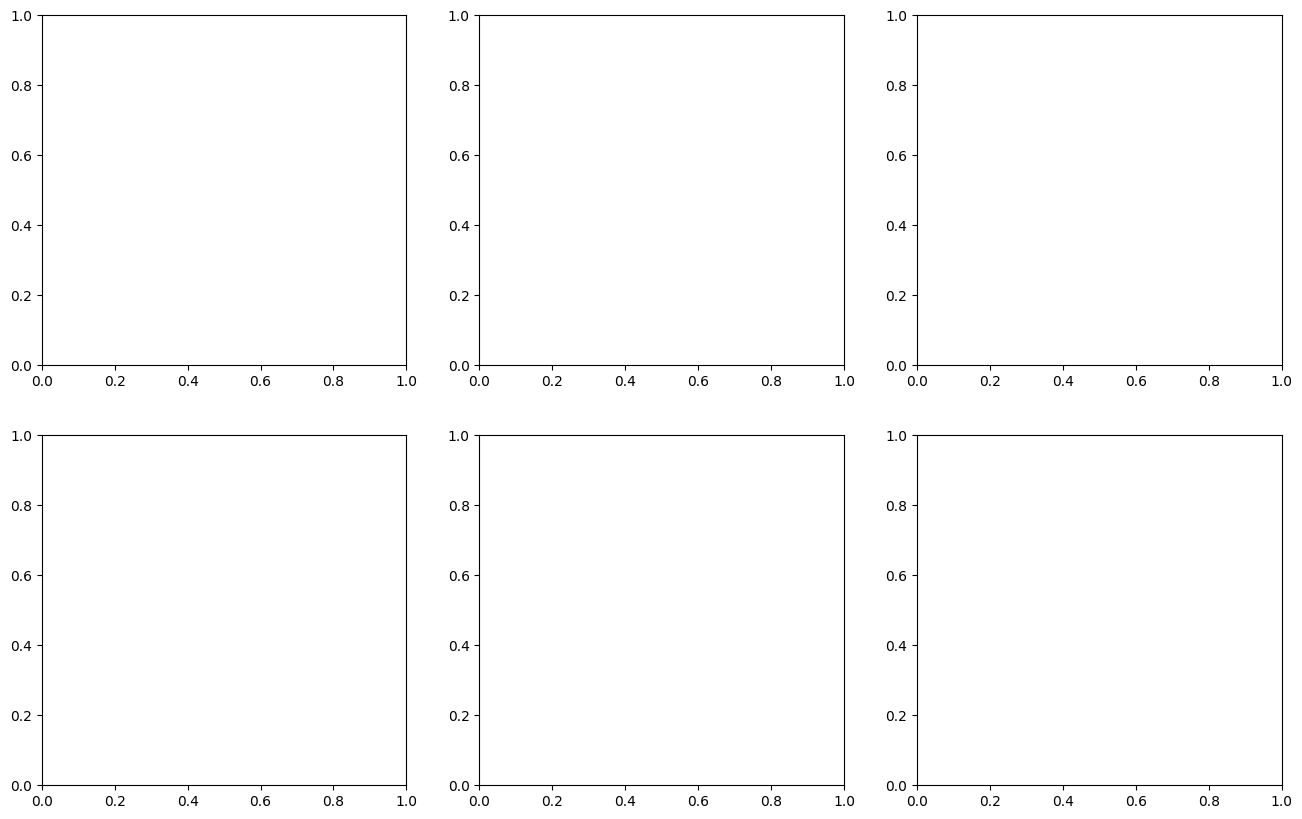

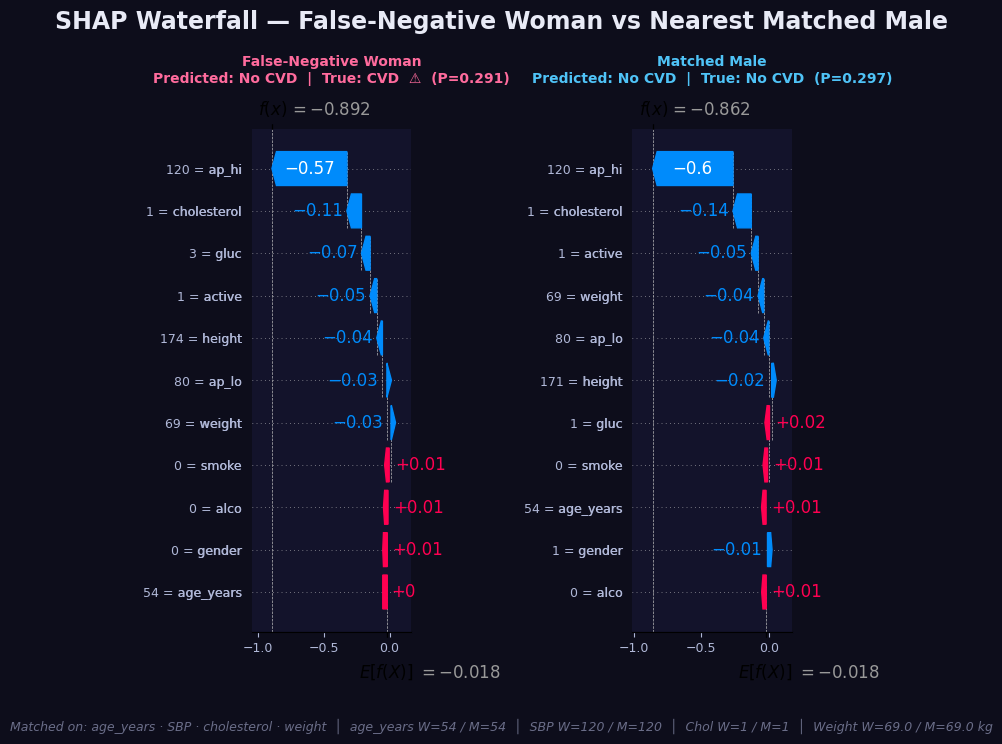


Top SHAP drivers (sorted by |woman SHAP|):
    feature  shap_woman  shap_male  diff (W-M)
      ap_hi     -0.5679    -0.5974     +0.0295
cholesterol     -0.1105    -0.1356     +0.0251
       gluc     -0.0655    +0.0166     -0.0820
     active     -0.0504    -0.0513     +0.0009
     height     -0.0428    -0.0210     -0.0218
      ap_lo     -0.0342    -0.0381     +0.0040
     weight     -0.0309    -0.0415     +0.0106
      smoke     +0.0137    +0.0138     -0.0000
       alco     +0.0088    +0.0095     -0.0006
     gender     +0.0055    -0.0105     +0.0160


In [15]:
# ── Additional code: SHAP False-Negative Analysis ────────────────────────────
# Paste this after your existing model evaluation code
# import shap


print(X_test.columns)
print(test_df.columns)
MATCHING_FEATURES = ["age_years", "ap_hi", "cholesterol", "weight"]  #FOR BASELINE
# MATCHING_FEATURES = ["age_years", "pulse_pressure", "chol_gluc_interact", "ap_hi_binned"] 

# 1. Identify false-negative women (true=1, predicted=0, gender=0)
fn_mask    = (y_test.values == 1) & (y_pred == 0) & (test_df["gender"].values == 0)
fn_women   = test_df[fn_mask].copy()
fn_women_X = X_test[fn_mask].copy()
print(f"False-negative women: {len(fn_women)}")

# 2. Pick most representative FN woman (closest to median profile)
fn_std     = fn_women[MATCHING_FEATURES].std().replace(0, 1)
fn_median  = fn_women[MATCHING_FEATURES].median()
distances  = fn_women[MATCHING_FEATURES].apply(
    lambda row: np.linalg.norm((row - fn_median) / fn_std), axis=1
)
rep_idx     = distances.idxmin()
rep_woman   = fn_women.loc[rep_idx]
rep_woman_X = X_test.loc[rep_idx]

# 3. Find nearest male in test set (z-score normalised L2 distance)
males   = test_df[test_df["gender"] == 1].copy()
males_X = X_test[test_df["gender"].values == 1].copy()

scaler = StandardScaler()
scaler.fit(pd.concat([fn_women[MATCHING_FEATURES], males[MATCHING_FEATURES]]))

woman_scaled = scaler.transform(rep_woman[MATCHING_FEATURES].values.reshape(1, -1))
males_scaled = scaler.transform(males[MATCHING_FEATURES])

best_pos   = np.argmin(np.linalg.norm(males_scaled - woman_scaled, axis=1))
rep_male   = males.iloc[best_pos]
rep_male_X = males_X.iloc[best_pos]

print("\nFeature comparison (woman vs matched male):")
print(pd.DataFrame({
    "FN Woman":     rep_woman[MATCHING_FEATURES].values,
    "Matched Male": rep_male[MATCHING_FEATURES].values,
}, index=MATCHING_FEATURES))

# 4. SHAP explanations
explainer = shap.TreeExplainer(model)
woman_df  = pd.DataFrame(rep_woman_X.values.reshape(1, -1), columns=X_test.columns)
male_df   = pd.DataFrame(rep_male_X.values.reshape(1, -1),  columns=X_test.columns)
sv_woman  = explainer(woman_df)
sv_male   = explainer(male_df)

prob_woman = model.predict_proba(woman_df.values)[0, 1]
prob_male  = model.predict_proba(male_df.values)[0, 1]

# 5. Side-by-side waterfall plots
fig, axes = plt.subplots(1, 2, figsize=(26, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="False-Negative Woman",
         subtitle=f"Predicted: No CVD  |  True: CVD  ⚠️  (P={prob_woman:.3f})",
         accent="#ff6b9d"),
    dict(sv=sv_male,  ax=axes[1], title="Matched Male",
         subtitle=f"Predicted: {'CVD' if model.predict(male_df.values)[0]==1 else 'No CVD'}  "
                  f"|  True: {'CVD' if rep_male['cardio']==1 else 'No CVD'}  (P={prob_male:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(f"{p['title']}\n{p['subtitle']}", color=p["accent"], fontsize=10, fontweight="bold", pad=12)    
fig.suptitle("SHAP Waterfall — False-Negative Woman vs Nearest Matched Male",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01,
         f"Matched on: age_years · SBP · cholesterol · weight  │  "
         f"age_years W={int(rep_woman['age_years'])} / M={int(rep_male['age_years'])}  │  "
         f"SBP W={int(rep_woman['ap_hi'])} / M={int(rep_male['ap_hi'])}  │  "
         f"Chol W={int(rep_woman['cholesterol'])} / M={int(rep_male['cholesterol'])}  │  "
         f"Weight W={rep_woman['weight']:.1f} / M={rep_male['weight']:.1f} kg",
         ha="center", fontsize=9, color="#6a6d88", style="italic")




plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.85)
plt.savefig("shap_fn_woman_vs_matched_male.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# 6. Console SHAP driver summary
print("\nTop SHAP drivers (sorted by |woman SHAP|):")
print(pd.DataFrame({
    "feature":    X_test.columns,
    "shap_woman": sv_woman[0].values,
    "shap_male":  sv_male[0].values,
    "diff (W-M)": sv_woman[0].values - sv_male[0].values,
}).sort_values("shap_woman", key=abs, ascending=False).head(10).to_string(
    index=False, float_format="{:+.4f}".format))



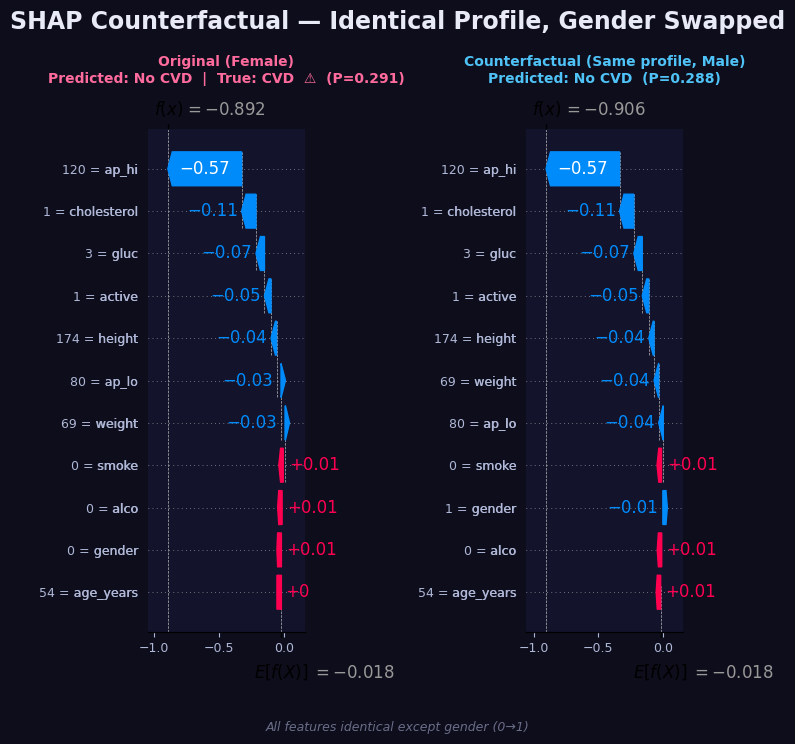


Original (Female) CVD probability:       0.291
Counterfactual (Male) CVD probability:   0.288
Probability difference (M-F):            -0.003


In [16]:
# 7. Counterfactual: swap gender for the FN woman
woman_counterfactual = woman_df.copy()
woman_counterfactual["gender"] = 1  # flip to male

sv_counterfactual = explainer(woman_counterfactual)
prob_counterfactual = model.predict_proba(woman_counterfactual.values)[0, 1]

# Plot original woman vs gender-swapped version
fig, axes = plt.subplots(1, 2, figsize=(26, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="Original (Female)",
         subtitle=f"Predicted: No CVD  |  True: CVD  ⚠️  (P={prob_woman:.3f})",
         accent="#ff6b9d"),
    dict(sv=sv_counterfactual, ax=axes[1], title="Counterfactual (Same profile, Male)",
         subtitle=f"Predicted: {'CVD' if model.predict(woman_counterfactual.values)[0]==1 else 'No CVD'}  (P={prob_counterfactual:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(f"{p['title']}\n{p['subtitle']}", color=p["accent"], fontsize=10, fontweight="bold", pad=12)

fig.suptitle("SHAP Counterfactual — Identical Profile, Gender Swapped",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01, "All features identical except gender (0→1)",
         ha="center", fontsize=9, color="#6a6d88", style="italic")

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.85)
plt.savefig("shap_counterfactual_gender.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"\nOriginal (Female) CVD probability:       {prob_woman:.3f}")
print(f"Counterfactual (Male) CVD probability:   {prob_counterfactual:.3f}")
print(f"Probability difference (M-F):            {prob_counterfactual - prob_woman:+.3f}")

In [17]:
# 1. Compare false-negative women vs true-positive women
tp_mask  = (y_test.values == 1) & (y_pred == 1) & (test_df["gender"].values == 0)
tp_women = test_df[tp_mask].copy()

# compare_features = ["age_years", "ap_hi", "ap_lo", "cholesterol", "gluc", "weight", "height", "smoke", "alco", "active"]
compare_features = test_df.columns.tolist()
compare_features = [c for c in compare_features 
                    if c not in ["cardio", "stratify"]]

summary_compare = pd.DataFrame({
    "FN_mean": fn_women[compare_features].mean(),
    "TP_mean": tp_women[compare_features].mean(),
    "FN_median": fn_women[compare_features].median(),
    "TP_median": tp_women[compare_features].median(),
    "Difference_FN_minus_TP": fn_women[compare_features].mean() - tp_women[compare_features].mean()
}).round(3)

print("\nFalse-negative women vs true-positive women:")
print(summary_compare.to_string())
# 2. Build SHAP tables for all female test cases
female_mask = (test_df["gender"].values == 0)
male_mask = (test_df["gender"].values == 1)


X_test_female = X_test[female_mask].copy()
test_female   = test_df[female_mask].copy()
y_test_female = y_test.values[female_mask]
y_pred_female = y_pred[female_mask]

sv_female = explainer(X_test_female)
shap_female_df = pd.DataFrame(sv_female.values, columns=X_test.columns, index=X_test_female.index)

shap_female_df["y_true"] = y_test_female
shap_female_df["y_pred"] = y_pred_female
shap_female_df["false_negative"] = ((shap_female_df["y_true"] == 1) & (shap_female_df["y_pred"] == 0)).astype(int)
shap_female_df["true_positive"]  = ((shap_female_df["y_true"] == 1) & (shap_female_df["y_pred"] == 1)).astype(int)
shap_female_df["true_negative"]  = ((shap_female_df["y_true"] == 0) & (shap_female_df["y_pred"] == 0)).astype(int)

# 3. Which features most strongly push down FN predictions?
# 9. Mean SHAP in FN vs TP women
fn_shap = shap_female_df[shap_female_df["false_negative"] == 1][X_test.columns]
tp_shap = shap_female_df[shap_female_df["true_positive"] == 1][X_test.columns]

shap_compare = pd.DataFrame({
    "FN_mean_SHAP": fn_shap.mean(),
    "TP_mean_SHAP": tp_shap.mean(),
    "Difference_FN_minus_TP": fn_shap.mean() - tp_shap.mean(),
    "FN_mean_abs_SHAP": fn_shap.abs().mean(),
    "TP_mean_abs_SHAP": tp_shap.abs().mean()
}).sort_values("Difference_FN_minus_TP")

print("\nMean SHAP comparison: FN women vs TP women")
print(shap_compare.round(4).to_string())

# Interpretation:

# very negative FN_mean_SHAP = feature pushes missed women toward “No CVD”

# FN_mean_SHAP much lower than TP_mean_SHAP = possible under-response or over-reassurance

# 4. Most common top negative feature in FN women
# 10. Most common dominant negative contributor in FN women
top_negative_feature_fn = fn_shap.idxmin(axis=1)
top_negative_counts = top_negative_feature_fn.value_counts()

print("\nMost common top negative SHAP feature in false-negative women:")
print(top_negative_counts.to_string())

# This is great for phrases like:

# “The most common dominant downward contributor in false-negative women was systolic blood pressure.”

# 5. Top 2 negative contributors per FN case
# # 11. Top 2 negative contributors per FN case
# def top_n_negative_features(row, n=2):
#     return row.sort_values().head(n).index.tolist()

# top2_neg_fn = fn_shap.apply(top_n_negative_features, axis=1)

# top2_df = pd.DataFrame(top2_neg_fn.tolist(), index=fn_shap.index, columns=["neg_1", "neg_2"])

# print("\nTop 2 negative contributors in first 10 FN women:")
# print(top2_df.head(10).to_string())
# # 6. Plot SHAP dependence for FN vs TP women for one feature
# # 12. FN vs TP dependence scatter for one feature
# import matplotlib.pyplot as plt

# feature = "ap_hi"
# idx = X_test.columns.get_loc(feature)

# fn_mask_female = shap_female_df["false_negative"] == 1
# tp_mask_female = shap_female_df["true_positive"] == 1

# plt.figure(figsize=(8, 6))
# plt.scatter(
#     X_test_female.loc[tp_mask_female, feature],
#     sv_female.values[tp_mask_female, idx],
#     alpha=0.35,
#     label="True Positive women"
# )
# plt.scatter(
#     X_test_female.loc[fn_mask_female, feature],
#     sv_female.values[fn_mask_female, idx],
#     alpha=0.75,
#     label="False Negative women"
# )
# plt.xlabel(feature)
# plt.ylabel(f"SHAP({feature})")
# plt.title(f"SHAP dependence: {feature} in TP vs FN women")
# plt.legend()
# plt.show()

# # Repeat this for:

# # "age_years"

# # "ap_hi"

# # "cholesterol"

# # "gluc"

# # 7. Predicted probability distribution for FN women
# # 13. Are false negatives near-misses or hard misses?
# y_pred_proba = model.predict_proba(X_test)[:, 1]
# test_df["pred_proba"] = y_pred_proba

# fn_women_probs = test_df.loc[fn_mask, "pred_proba"]
# tp_women_probs = test_df.loc[tp_mask, "pred_proba"]

# print("\nPredicted probability summary:")
# print("FN women:")
# print(fn_women_probs.describe().round(4).to_string())

# print("\nTP women:")
# print(tp_women_probs.describe().round(4).to_string())

# # This tells you whether FN women were:

# # just below threshold

# # or strongly misclassified as low risk

# # 8. Simple error phenotype table
# # 14. Simple FN phenotype summary using dominant negative feature
# fn_pattern_table = pd.DataFrame({
#     "dominant_negative_feature": top_negative_feature_fn
# })

# print("\nFalse-negative phenotype summary:")
# print(fn_pattern_table["dominant_negative_feature"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


False-negative women vs true-positive women:
             FN_mean  TP_mean  FN_median  TP_median  Difference_FN_minus_TP
gender         0.000    0.000        0.0        0.0                   0.000
height       162.514  160.835      163.0      160.0                   1.678
weight        70.200   77.460       69.0       75.0                  -7.260
ap_hi        117.614  140.970      120.0      140.0                 -23.356
ap_lo         77.247   87.331       80.0       90.0                 -10.084
cholesterol    1.176    1.708        1.0        1.0                  -0.532
gluc           1.155    1.362        1.0        1.0                  -0.208
smoke          0.013    0.018        0.0        0.0                  -0.005
alco           0.021    0.028        0.0        0.0                  -0.006
active         0.813    0.783        1.0        1.0                   0.030
age_years     52.956   55.883       54.0       57.0                  -2.927

Mean SHAP comparison: FN women vs TP wome

## Raw values : FN vs TP women
Okay so 


Top 2 negative contributors in first 10 FN women:
           neg_1        neg_2
7          ap_hi  cholesterol
19         ap_hi  cholesterol
30         ap_hi       height
47         ap_hi       weight
61         ap_hi  cholesterol
78         ap_hi  cholesterol
92         ap_hi         alco
108        ap_hi    age_years
130        ap_hi  cholesterol
138  cholesterol        ap_lo


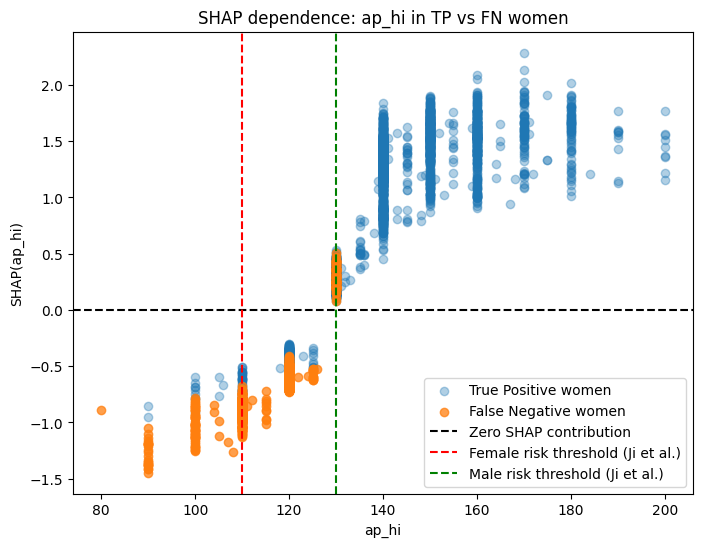

In [18]:
# “The most common dominant downward contributor in false-negative women was systolic blood pressure.”

# 5. Top 2 negative contributors per FN case
# 11. Top 2 negative contributors per FN case
def top_n_negative_features(row, n=2):
    return row.sort_values().head(n).index.tolist()

top2_neg_fn = fn_shap.apply(top_n_negative_features, axis=1)

top2_df = pd.DataFrame(top2_neg_fn.tolist(), index=fn_shap.index, columns=["neg_1", "neg_2"])

print("\nTop 2 negative contributors in first 10 FN women:")
print(top2_df.head(10).to_string())
# 6. Plot SHAP dependence for FN vs TP women for one feature
# 12. FN vs TP dependence scatter for one feature
import matplotlib.pyplot as plt

feature = "ap_hi"
idx = X_test.columns.get_loc(feature)

fn_mask_female = shap_female_df["false_negative"] == 1
tp_mask_female = shap_female_df["true_positive"] == 1

plt.figure(figsize=(8, 6))
plt.scatter(
    X_test_female.loc[tp_mask_female, feature],
    sv_female.values[tp_mask_female, idx],
    alpha=0.35,
    label="True Positive women"
)
plt.scatter(
    X_test_female.loc[fn_mask_female, feature],
    sv_female.values[fn_mask_female, idx],
    alpha=0.75,
    label="False Negative women"
)

# Reference lines
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, 
            label="Zero SHAP contribution")
plt.axvline(x=110, color='red', linestyle='--', linewidth=1.5,
            label="Female risk threshold (Ji et al.)")
plt.axvline(x=130, color='green', linestyle='--', linewidth=1.5,
            label="Male risk threshold (Ji et al.)")
plt.xlabel(feature)
plt.ylabel(f"SHAP({feature})")
plt.title(f"SHAP dependence: {feature} in TP vs FN women")
plt.legend()
plt.show()

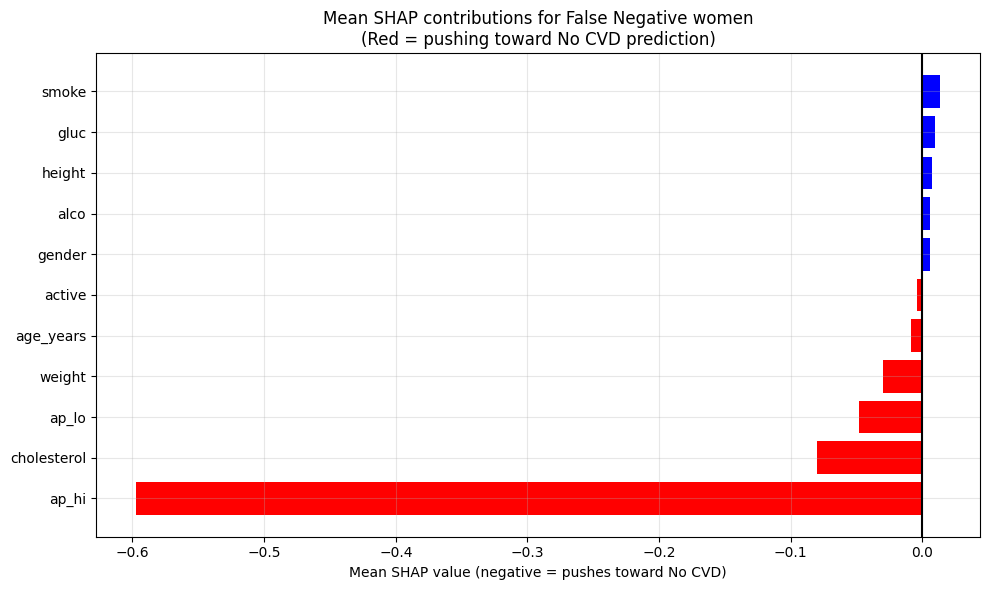

ap_hi         -0.597191
cholesterol   -0.080068
ap_lo         -0.048155
weight        -0.030138
age_years     -0.008486
active        -0.004228
gender         0.005868
alco           0.006081
height         0.007092
gluc           0.009171
smoke          0.013164
dtype: float32


In [19]:
# Mean SHAP contributions for FN women
fn_mean_shap = fn_shap.mean().sort_values()

colors = ["red" if v < 0 else "blue" for v in fn_mean_shap.values]

plt.figure(figsize=(10, 6))
plt.barh(fn_mean_shap.index, fn_mean_shap.values, color=colors)
plt.axvline(x=0, color='black', linewidth=1.5)
plt.xlabel("Mean SHAP value (negative = pushes toward No CVD)")
plt.title("Mean SHAP contributions for False Negative women\n(Red = pushing toward No CVD prediction)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(fn_mean_shap)

In [20]:
# import numpy as np

# features = ["age_years", "ap_hi", "ap_lo", "cholesterol", "gluc", "weight"]

# fn_means = [fn_women[f].mean() for f in features]
# tp_means = [tp_women[f].mean() for f in features]

# x = np.arange(len(features))
# width = 0.35

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.bar(x - width/2, fn_means, width, label="FN Women", color="orange", alpha=0.8)
# ax.bar(x + width/2, tp_means, width, label="TP Women", color="blue", alpha=0.8)

# ax.set_xticks(x)
# ax.set_xticklabels(features, rotation=45)
# ax.set_title("Mean Feature Values: FN vs TP Women")
# ax.legend()
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

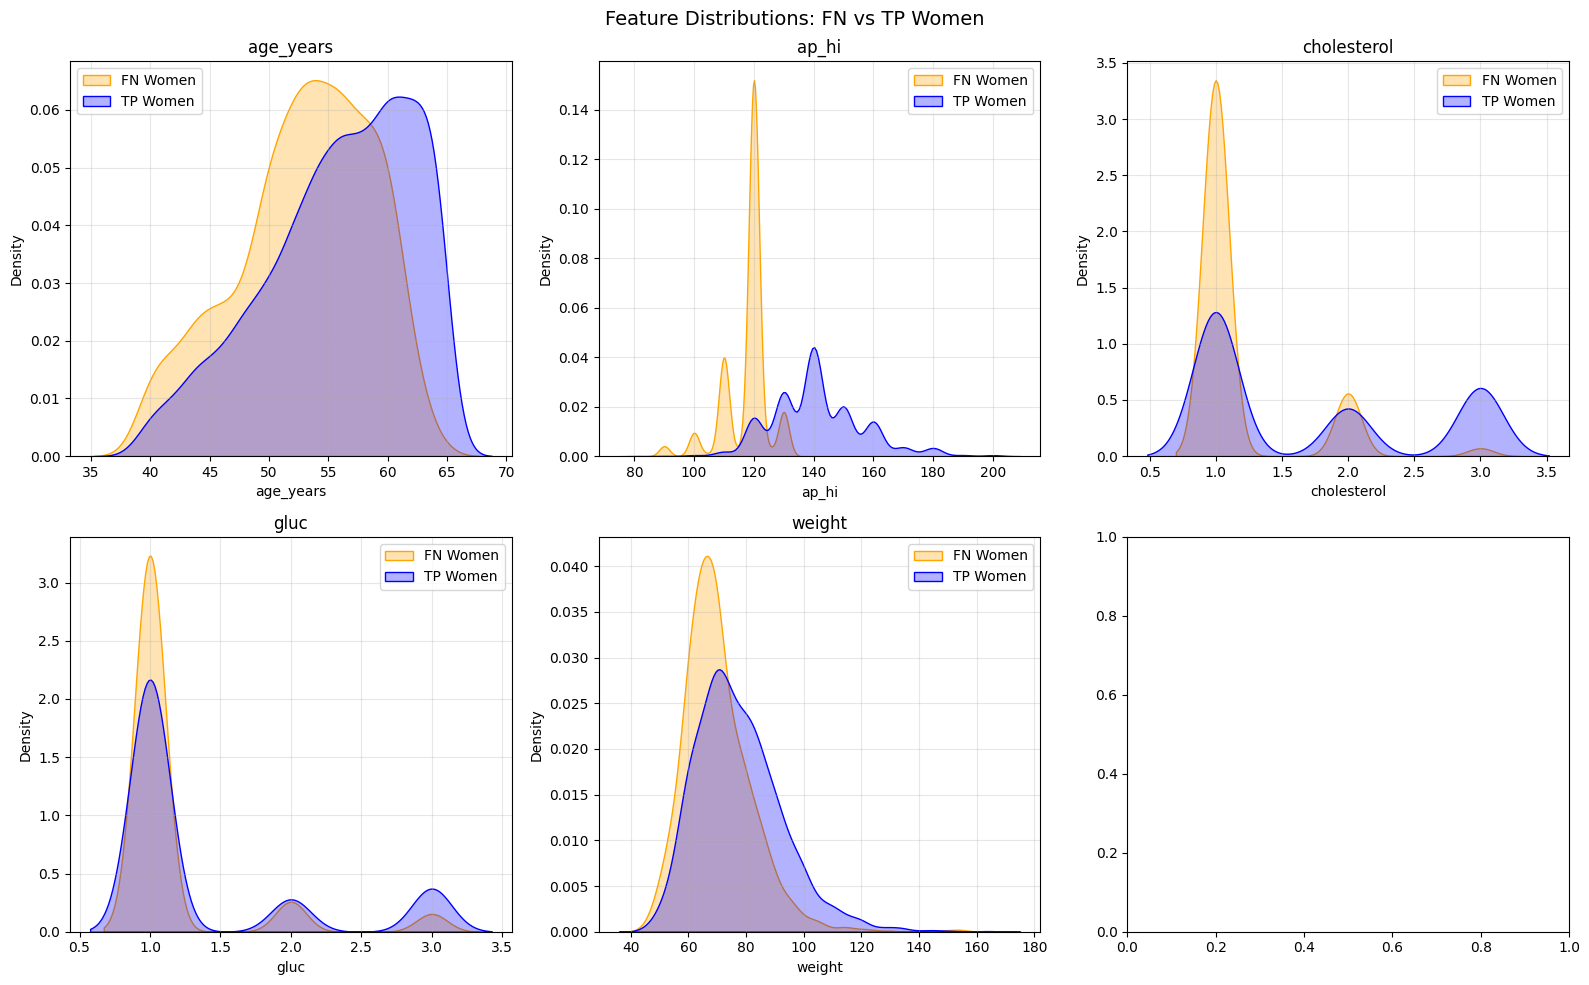

In [21]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    sns.kdeplot(fn_women[feature], ax=axes[idx], 
                label="FN Women", color="orange", fill=True, alpha=0.3)
    sns.kdeplot(tp_women[feature], ax=axes[idx], 
                label="TP Women", color="blue", fill=True, alpha=0.3)
    axes[idx].set_title(feature)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

    # Add clinical reference line for ap_hi
    if feature == "ap_hi_binned":
        axes[idx].axvline(x=100, color='red', linestyle='--', 
                         linewidth=1.5, label="Female risk threshold (Ji et al.)")
        axes[idx].legend()

plt.suptitle("Feature Distributions: FN vs TP Women", fontsize=14)
plt.tight_layout()
plt.show()

Man FN vs TP just to reference


In [22]:
# True Positive males
tp_mask_male = (y_test.values == 1) & (y_pred == 1) & (test_df["gender"].values == 1)
tp_men = test_df[tp_mask_male].copy()

# False Negative males
fn_mask_male = (y_test.values == 1) & (y_pred == 0) & (test_df["gender"].values == 1)
fn_men = test_df[fn_mask_male].copy()

In [23]:
summary_compare_male = pd.DataFrame({
    "FN_mean": fn_men[compare_features].mean(),
    "TP_mean": tp_men[compare_features].mean(),
    "FN_median": fn_men[compare_features].median(),
    "TP_median": tp_men[compare_features].median(),
    "Difference_FN_minus_TP": fn_men[compare_features].mean() - tp_men[compare_features].mean()
}).round(3)

print("\nFalse-negative men vs true-positive men:")
print(summary_compare_male.to_string())


False-negative men vs true-positive men:
             FN_mean  TP_mean  FN_median  TP_median  Difference_FN_minus_TP
gender         1.000    1.000        1.0        1.0                   0.000
height       170.147  170.394      170.0      170.0                  -0.247
weight        75.348   81.364       74.0       79.0                  -6.016
ap_hi        118.524  142.718      120.0      140.0                 -24.193
ap_lo         78.135   88.330       80.0       90.0                 -10.195
cholesterol    1.132    1.609        1.0        1.0                  -0.477
gluc           1.192    1.271        1.0        1.0                  -0.079
smoke          0.226    0.219        0.0        0.0                   0.007
alco           0.091    0.109        0.0        0.0                  -0.018
active         0.805    0.774        1.0        1.0                   0.031
age_years     52.775   55.432       54.0       56.0                  -2.657


In [24]:
X_test_male = X_test[male_mask].copy()
test_male   = test_df[male_mask].copy()
y_test_male = y_test.values[male_mask]
y_pred_male = y_pred[male_mask]

sv_male = explainer(X_test_male)

shap_male_df = pd.DataFrame(
    sv_male.values,
    columns=X_test.columns,
    index=X_test_male.index
)

shap_male_df["y_true"] = y_test_male
shap_male_df["y_pred"] = y_pred_male
shap_male_df["false_negative"] = ((shap_male_df["y_true"] == 1) & (shap_male_df["y_pred"] == 0)).astype(int)
shap_male_df["true_positive"]  = ((shap_male_df["y_true"] == 1) & (shap_male_df["y_pred"] == 1)).astype(int)

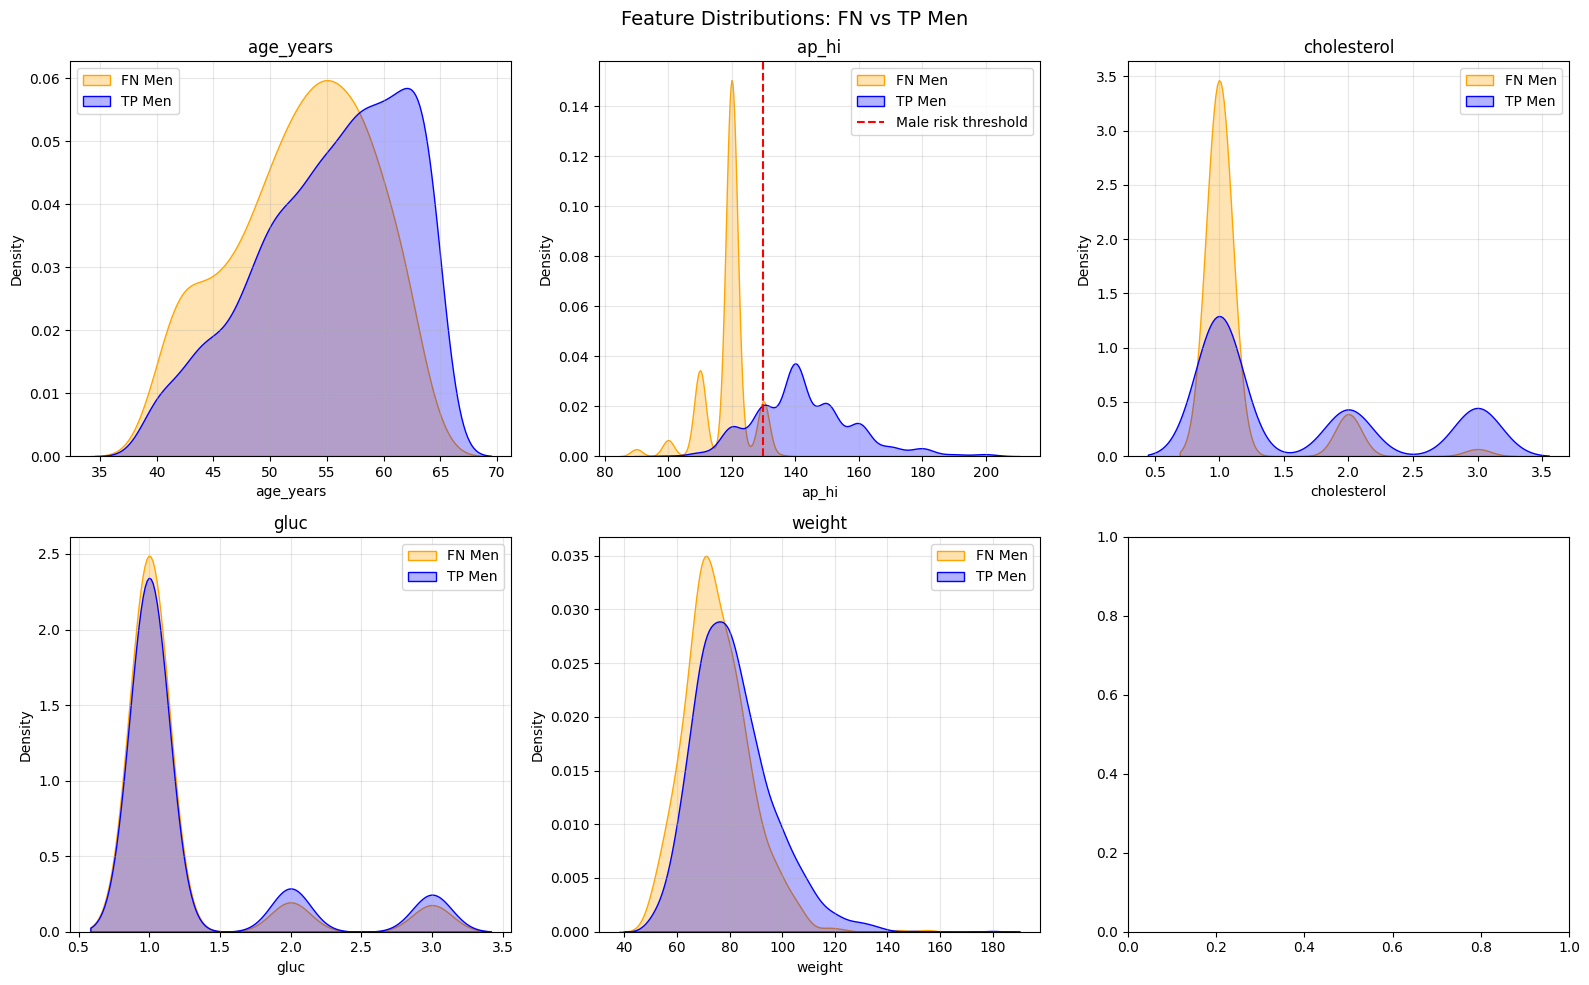

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt



fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    sns.kdeplot(fn_men[feature], ax=axes[idx], 
                label="FN Men", color="orange", fill=True, alpha=0.3)
    sns.kdeplot(tp_men[feature], ax=axes[idx], 
                label="TP Men", color="blue", fill=True, alpha=0.3)
    
    axes[idx].set_title(feature)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

    # Add clinical reference line for systolic BP (male threshold example)
    if feature == "ap_hi":
        axes[idx].axvline(x=130, color='red', linestyle='--', 
                         linewidth=1.5, label="Male risk threshold")
        axes[idx].legend()

plt.suptitle("Feature Distributions: FN vs TP Men", fontsize=14)
plt.tight_layout()
plt.show()

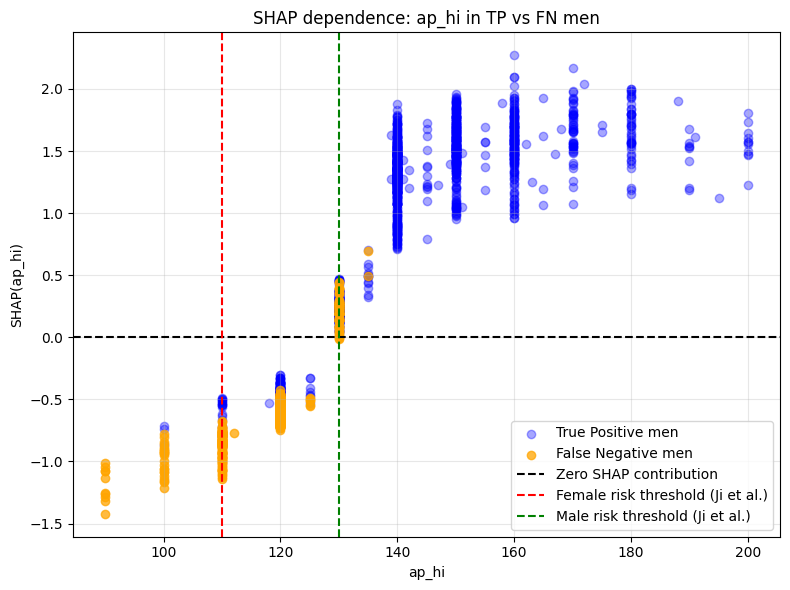

In [26]:
feature = "ap_hi"
idx = X_test_male.columns.get_loc(feature)

# Get male positions in full test set
male_positions = (test_df["gender"].values == 1)

# Extract just the male rows from the full masks
fn_mask_male_sub = fn_mask_male[male_positions]
tp_mask_male_sub = tp_mask_male[male_positions]

X_male_reset = X_test_male.reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_male_reset.loc[tp_mask_male_sub, feature],
    sv_male.values[tp_mask_male_sub, idx],
    alpha=0.35, label="True Positive men", color="blue"
)
plt.scatter(
    X_male_reset.loc[fn_mask_male_sub, feature],
    sv_male.values[fn_mask_male_sub, idx],
    alpha=0.75, label="False Negative men", color="orange"
)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5,
            label="Zero SHAP contribution")
plt.axvline(x=110, color='red', linestyle='--', linewidth=1.5,
            label="Female risk threshold (Ji et al.)")
plt.axvline(x=130, color='green', linestyle='--', linewidth=1.5,
            label="Male risk threshold (Ji et al.)")

plt.xlabel(feature)
plt.ylabel(f"SHAP({feature})")
plt.title(f"SHAP dependence: {feature} in TP vs FN men")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import recall_score

female_recall = recall_score(y_test[female_mask], y_pred[female_mask])
male_recall = recall_score(y_test[male_mask], y_pred[male_mask])

print(f"Female Recall (Sensitivity): {female_recall:.3f}")
print(f"Male Recall (Sensitivity): {male_recall:.3f}")

Female Recall (Sensitivity): 0.689
Male Recall (Sensitivity): 0.673


True Negative women: 3551
TN women with BP >= 110mmHg: 3039
As % of all TN women: 85.6%

Of those, age >= 45 (peri-menopausal):
Count: 2380
As % of TN women: 67.0%

TN women in clinical risk zone vs not:
             At risk (BP>=110)  Not at risk (BP<110)
age_years                50.71                 48.57
ap_hi                   117.51                 97.42
cholesterol               1.12                  1.18


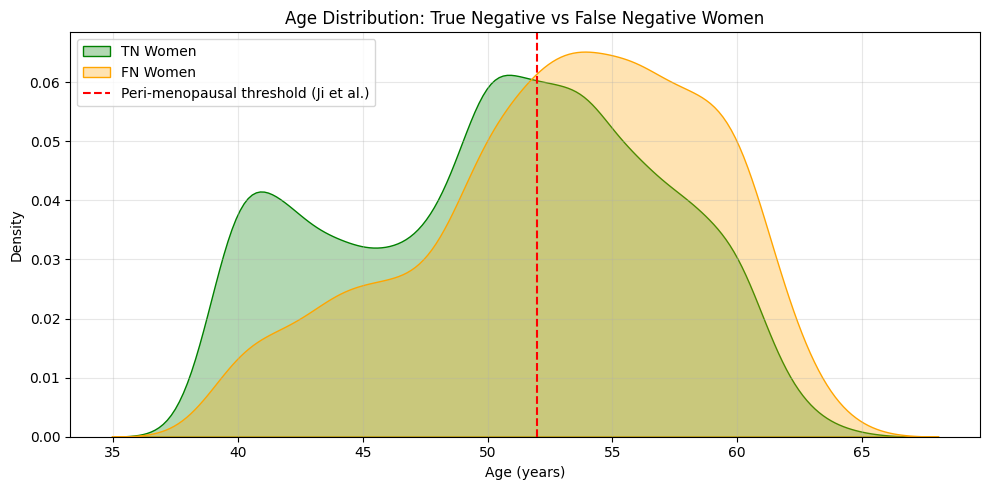

TN women mean age: 50.4
FN women mean age: 53.0
TN women age >= 45: 2717 (76.5%)
FN women age >= 45: 1204 (88.6%)


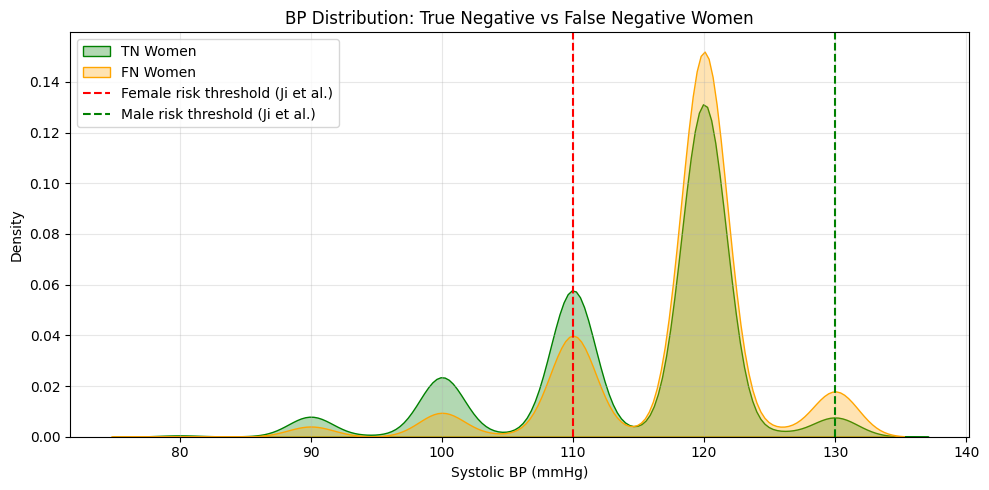

In [28]:
# # Compare FN vs TP women for mean SHAP by feature
# import pandas as pd
# import matplotlib.pyplot as plt

# # masks
# female_mask = (X_test["gender"].values == 0)
# 
# 
# 
# = female_mask & (y_test.values == 1) & (y_pred == 0)
# tp_mask = female_mask & (y_test.values == 1) & (y_pred == 1)

# # SHAP values for all test women
# explainer = shap.TreeExplainer(model)
# sv_all = explainer(X_test).values
# shap_df = pd.DataFrame(sv_all, columns=X_test.columns, index=X_test.index)

# # mean SHAP comparison
# fn_mean_shap = shap_df.loc[fn_mask].mean()
# tp_mean_shap = shap_df.loc[tp_mask].mean()

# compare = pd.DataFrame({
#     "FN_mean_SHAP": fn_mean_shap,
#     "TP_mean_SHAP": tp_mean_shap,
#     "Difference_FN_minus_TP": fn_mean_shap - tp_mean_shap,
#     "FN_abs_SHAP": shap_df.loc[fn_mask].abs().mean(),
#     "TP_abs_SHAP": shap_df.loc[tp_mask].abs().mean()
# }).sort_values("Difference_FN_minus_TP")

# print(compare.round(4).to_string())

# # features you care about most

# # bar plot of mean SHAP difference
# plt.figure(figsize=(8, 5))
# compare.loc[features_to_plot, "Difference_FN_minus_TP"].sort_values().plot(kind="barh")
# plt.xlabel("FN mean SHAP - TP mean SHAP")
# plt.ylabel("Feature")
# plt.title("False-negative vs true-positive women: mean SHAP difference")
# plt.tight_layout()
# plt.show()

# # FN vs TP dependence scatter for selected features
# for feature in features_to_plot:
#     idx = X_test.columns.get_loc(feature)

#     plt.figure(figsize=(7, 5))
#     plt.scatter(
#         X_test.loc[tp_mask, feature],
#         sv_all[tp_mask, idx],
#         alpha=0.35,
#         label="TP women"
#     )
#     plt.scatter(
#         X_test.loc[fn_mask, feature],
#         sv_all[fn_mask, idx],
#         alpha=0.7,
#         label="FN women"
#     )
#     plt.xlabel(feature)
#     plt.ylabel(f"SHAP({feature})")
#     plt.title(f"{feature}: TP vs FN women")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


# True Negative women — model says No CVD, label says No CVD
tn_mask_female = (y_test.values == 0) & (y_pred == 0) & (test_df["gender"].values == 0)
tn_women = test_df[tn_mask_female].copy()

print(f"True Negative women: {len(tn_women)}")

# How many TN women are in the female clinical risk zone?
# Ji et al. says women face significant CVD risk from 110mmHg
clinically_at_risk = tn_women[tn_women["ap_hi"] >= 110]
print(f"TN women with BP >= 110mmHg: {len(clinically_at_risk)}")
print(f"As % of all TN women: {len(clinically_at_risk)/len(tn_women)*100:.1f}%")

# Age distribution of clinically at risk TN women
print(f"\nOf those, age >= 45 (peri-menopausal):")
peri_menopausal = clinically_at_risk[clinically_at_risk["age_years"] >= 45]
print(f"Count: {len(peri_menopausal)}")
print(f"As % of TN women: {len(peri_menopausal)/len(tn_women)*100:.1f}%")

# Compare feature profiles
print("\nTN women in clinical risk zone vs not:")
print(pd.DataFrame({
    "At risk (BP>=110)":     clinically_at_risk[["age_years", "ap_hi", "cholesterol"]].mean(),
    "Not at risk (BP<110)":  tn_women[tn_women["ap_hi"] < 110][["age_years", "ap_hi", "cholesterol"]].mean()
}).round(2))

plt.figure(figsize=(10, 5))
sns.kdeplot(tn_women["age_years"], color="green", fill=True, alpha=0.3, label="TN Women")
sns.kdeplot(fn_women["age_years"], color="orange", fill=True, alpha=0.3, label="FN Women")
plt.axvline(x=52, color='red', linestyle='--', linewidth=1.5,
            label="Peri-menopausal threshold (Ji et al.)")
plt.title("Age Distribution: True Negative vs False Negative Women")
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"TN women mean age: {tn_women['age_years'].mean():.1f}")
print(f"FN women mean age: {fn_women['age_years'].mean():.1f}")
print(f"TN women age >= 45: {(tn_women['age_years'] >= 45).sum()} ({(tn_women['age_years'] >= 45).mean()*100:.1f}%)")
print(f"FN women age >= 45: {(fn_women['age_years'] >= 45).sum()} ({(fn_women['age_years'] >= 45).mean()*100:.1f}%)")

# Plot BP distribution of TN women
plt.figure(figsize=(10, 5))
sns.kdeplot(tn_women["ap_hi"], color="green", fill=True, alpha=0.3, label="TN Women")
sns.kdeplot(fn_women["ap_hi"], color="orange", fill=True, alpha=0.3, label="FN Women")
plt.axvline(x=110, color='red', linestyle='--', linewidth=1.5,
            label="Female risk threshold (Ji et al.)")
plt.axvline(x=130, color='green', linestyle='--', linewidth=1.5,
            label="Male risk threshold (Ji et al.)")
plt.title("BP Distribution: True Negative vs False Negative Women")
plt.xlabel("Systolic BP (mmHg)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [29]:
# import numpy as np
from sklearn.metrics import confusion_matrix

# Reuse existing variables
female_mask = (test_df["gender"].values == 0)
male_mask   = (test_df["gender"].values == 1)

# TPR per group
def tpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

tpr_male   = tpr(y_test[male_mask],   y_pred[male_mask])
tpr_female = tpr(y_test[female_mask], y_pred[female_mask])

# Positive prediction rate per group
pos_rate_male   = y_pred[male_mask].mean()
pos_rate_female = y_pred[female_mask].mean()

# EOD and DI
eod = tpr_male - tpr_female
di  = pos_rate_female / pos_rate_male

print(f"TPR Male             : {tpr_male:.4f}")
print(f"TPR Female           : {tpr_female:.4f}")
print(f"EOD (0 = fair)       : {eod:.4f}")
print(f"Pos Rate Male        : {pos_rate_male:.4f}")
print(f"Pos Rate Female      : {pos_rate_female:.4f}")
print(f"DI  (1 = fair)       : {di:.4f}")
print(f"\nLi et al. (2023) EOD range : 0.131 - 0.136")
print(f"Li et al. (2023) DI range  : 1.535 - 1.587")

TPR Male             : 0.6734
TPR Female           : 0.6893
EOD (0 = fair)       : -0.0159
Pos Rate Male        : 0.4440
Pos Rate Female      : 0.4462
DI  (1 = fair)       : 1.0049

Li et al. (2023) EOD range : 0.131 - 0.136
Li et al. (2023) DI range  : 1.535 - 1.587


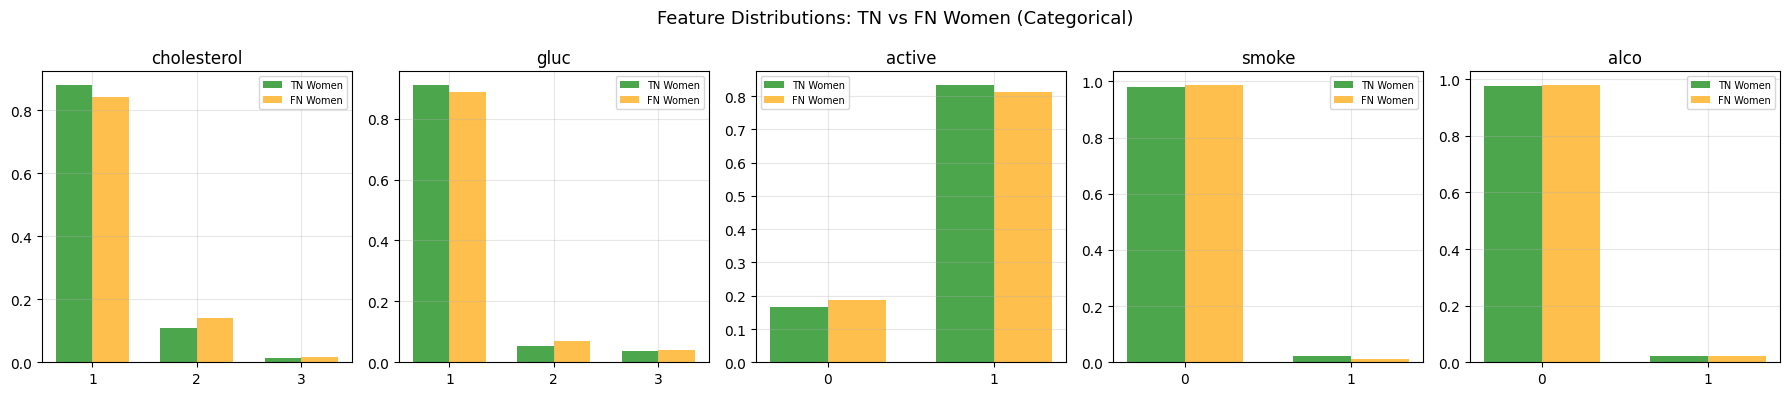

In [30]:
features_to_compare = ["cholesterol", "gluc", "active", "smoke", "alco"]

fig, axes = plt.subplots(1, len(features_to_compare), figsize=(18, 4))

for ax, feature in zip(axes, features_to_compare):
    tn_counts = tn_women[feature].value_counts(normalize=True).sort_index()
    fn_counts = fn_women[feature].value_counts(normalize=True).sort_index()
    
    x = range(len(tn_counts))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], tn_counts.values, 
           width, label="TN Women", color="green", alpha=0.7)
    ax.bar([i + width/2 for i in x], fn_counts.values, 
           width, label="FN Women", color="orange", alpha=0.7)
    
    ax.set_xticks(list(x))
    ax.set_xticklabels(tn_counts.index)
    ax.set_title(feature)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Feature Distributions: TN vs FN Women (Categorical)", fontsize=13)
plt.tight_layout()
plt.show()

True Negative men: 1874
False Negative men: 778


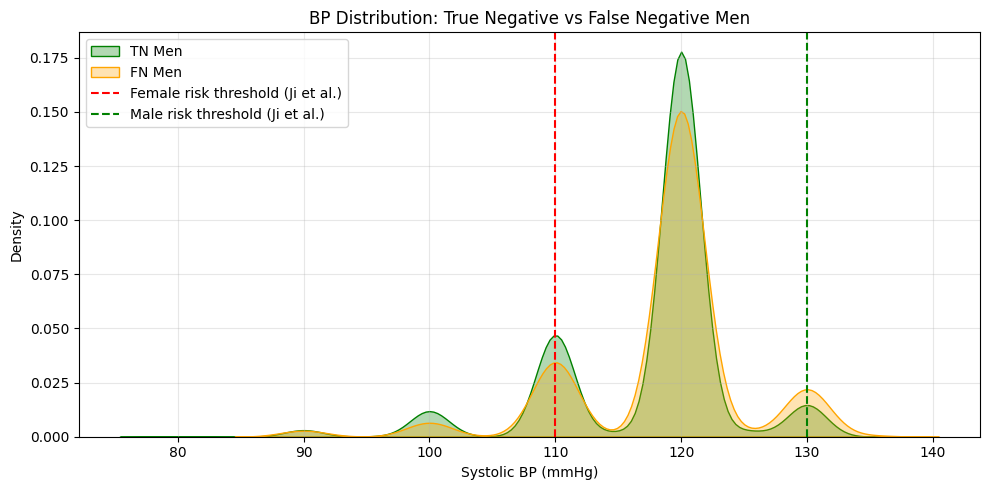

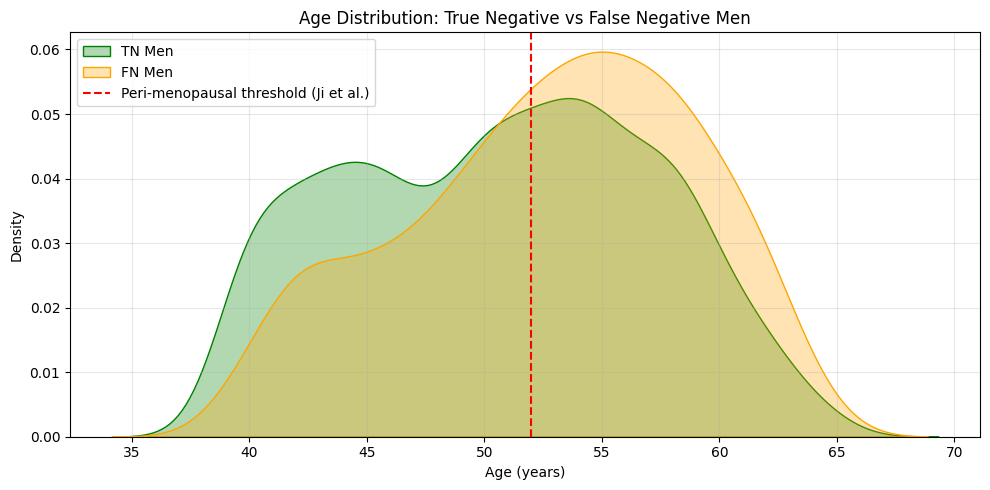


TN men mean BP  : 117.5
FN men mean BP  : 118.5
TN men mean age : 50.6
FN men mean age : 52.8

TN men with BP >= 130mmHg: 105 (5.6%)
FN men with BP >= 130mmHg: 80 (10.3%)


In [31]:
# True Negative men
tn_mask_male = (y_test.values == 0) & (y_pred == 0) & (test_df["gender"].values == 1)
tn_men = test_df[tn_mask_male].copy()

print(f"True Negative men: {len(tn_men)}")
print(f"False Negative men: {len(fn_men)}")

# BP distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(tn_men["ap_hi"], color="green", fill=True, alpha=0.3, label="TN Men")
sns.kdeplot(fn_men["ap_hi"], color="orange", fill=True, alpha=0.3, label="FN Men")
plt.axvline(x=110, color='red', linestyle='--', linewidth=1.5,
            label="Female risk threshold (Ji et al.)")
plt.axvline(x=130, color='green', linestyle='--', linewidth=1.5,
            label="Male risk threshold (Ji et al.)")
plt.title("BP Distribution: True Negative vs False Negative Men")
plt.xlabel("Systolic BP (mmHg)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Age distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(tn_men["age_years"], color="green", fill=True, alpha=0.3, label="TN Men")
sns.kdeplot(fn_men["age_years"], color="orange", fill=True, alpha=0.3, label="FN Men")
plt.axvline(x=52, color='red', linestyle='--', linewidth=1.5,
            label="Peri-menopausal threshold (Ji et al.)")
plt.title("Age Distribution: True Negative vs False Negative Men")
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTN men mean BP  : {tn_men['ap_hi'].mean():.1f}")
print(f"FN men mean BP  : {fn_men['ap_hi'].mean():.1f}")
print(f"TN men mean age : {tn_men['age_years'].mean():.1f}")
print(f"FN men mean age : {fn_men['age_years'].mean():.1f}")
print(f"\nTN men with BP >= 130mmHg: {(tn_men['ap_hi'] >= 130).sum()} ({(tn_men['ap_hi'] >= 130).mean()*100:.1f}%)")
print(f"FN men with BP >= 130mmHg: {(fn_men['ap_hi'] >= 130).sum()} ({(fn_men['ap_hi'] >= 130).mean()*100:.1f}%)")

In [32]:
tn_mask_female = shap_female_df["true_negative"] == 1

FN_women = shap_female_df[fn_mask_female].copy()
TN_women = shap_female_df[tn_mask_female].copy()

FN_women["group"] = "FN"
TN_women["group"] = "TN"


C:\Users\kavis\AppData\Local\Temp\ipykernel_8368\2321439161.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\kavis\AppData\Local\Temp\ipykernel_8368\2321439161.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\kavis\AppData\Local\Temp\ipykernel_8368\2321439161.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\kavis\AppData\Local\Temp\ipykernel_8368\2321439161.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

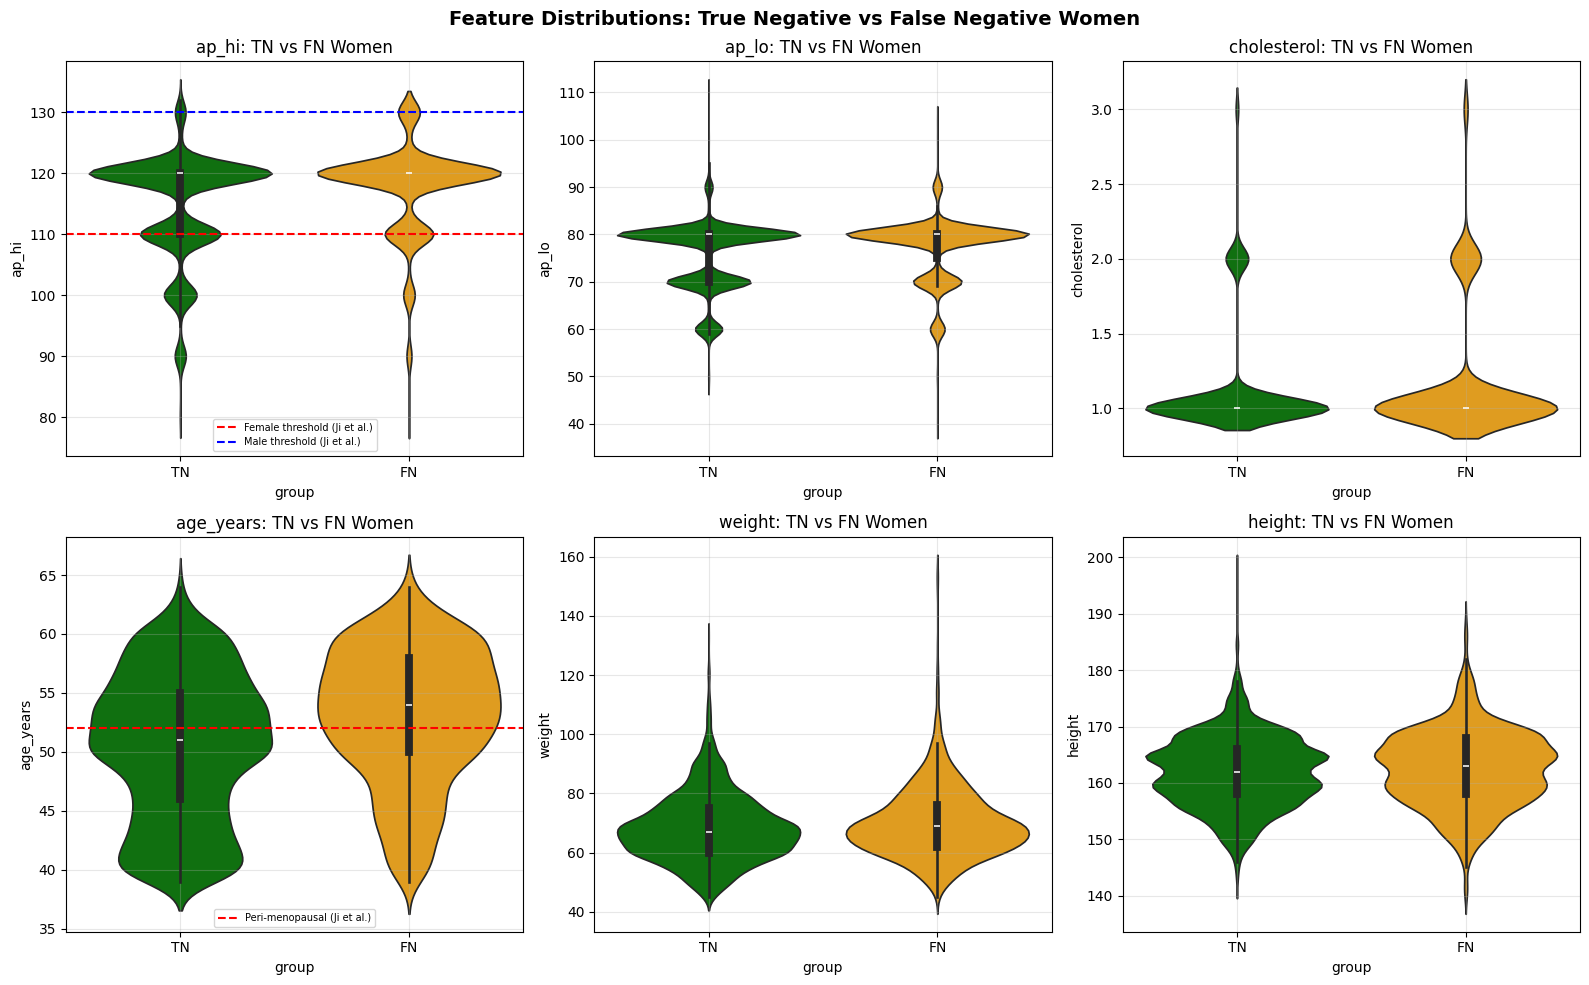

In [33]:


features = ["ap_hi", "ap_lo", "cholesterol", "age_years", "weight", "height"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    
    tn_plot = tn_women[[feature]].copy()
    tn_plot["group"] = "TN"
    fn_plot = fn_women[[feature]].copy()
    fn_plot["group"] = "FN"
    
    combined = pd.concat([tn_plot, fn_plot])
    
    sns.violinplot(
        data=combined,
        x="group",
        y=feature,
        palette={"TN": "green", "FN": "orange"},
        ax=axes[idx]
    )
    
    # Add clinical reference lines where relevant
    if feature == "ap_hi":
        axes[idx].axhline(y=110, color='red', linestyle='--', 
                          linewidth=1.5, label="Female threshold (Ji et al.)")
        axes[idx].axhline(y=130, color='blue', linestyle='--', 
                          linewidth=1.5, label="Male threshold (Ji et al.)")
        axes[idx].legend(fontsize=7)
    
    if feature == "age_years":
        axes[idx].axhline(y=52, color='red', linestyle='--',
                          linewidth=1.5, label="Peri-menopausal (Ji et al.)")
        axes[idx].legend(fontsize=7)
    
    axes[idx].set_title(f"{feature}: TN vs FN Women")
    axes[idx].grid(alpha=0.3)

plt.suptitle("Feature Distributions: True Negative vs False Negative Women",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
